<a href="https://colab.research.google.com/github/chuancao26/islp/blob/main/labSVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install ISLP

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 30.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 350.0/350.0 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 37.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 7.6 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=a6869d454abca23c0791cb2a334b836f3961f5a1964cac65f17926e805236487
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


# Librerias

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn.model_selection as skm
from sklearn.svm import SVC
from sklearn.metrics import RocCurveDisplay

from ISLP import load_data, confusion_table
from ISLP.svm import plot  as plot_svm

roc_curve = RocCurveDisplay.from_estimator




# Support Vector Classifier

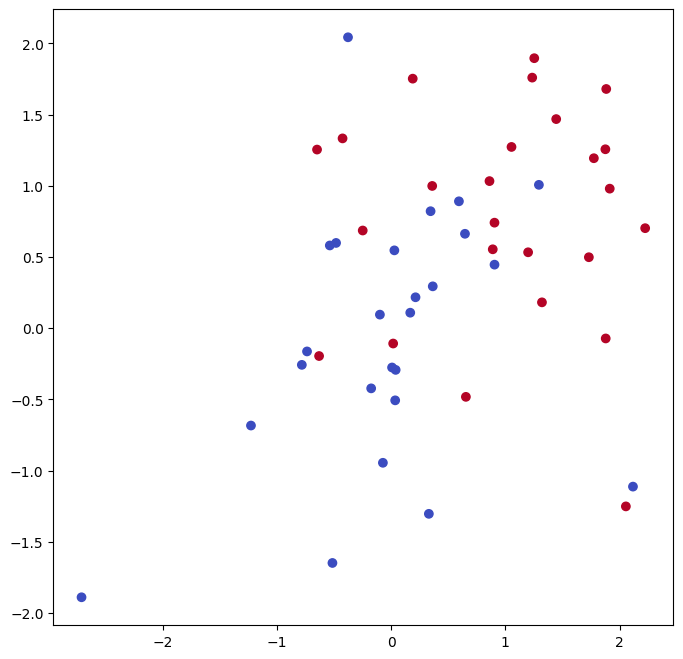

In [9]:
# generamos la data
rng = np.random.default_rng(1)

X = rng.standard_normal((50, 2))
y = np.array([-1] * 25 + [1] * 25)
X[y==1] += 1

fig, ax = plt.subplots(figsize=(8,8))
ax.scatter(X[:, 0],
           X[:, 1],
           c=y,
           cmap=plt.cm.coolwarm);

Las clases no son visiblemente separables

In [23]:
svm_linear = SVC(C=10, kernel='linear')
svm_linear.fit(X, y)

SVC(C=10, kernel='linear')

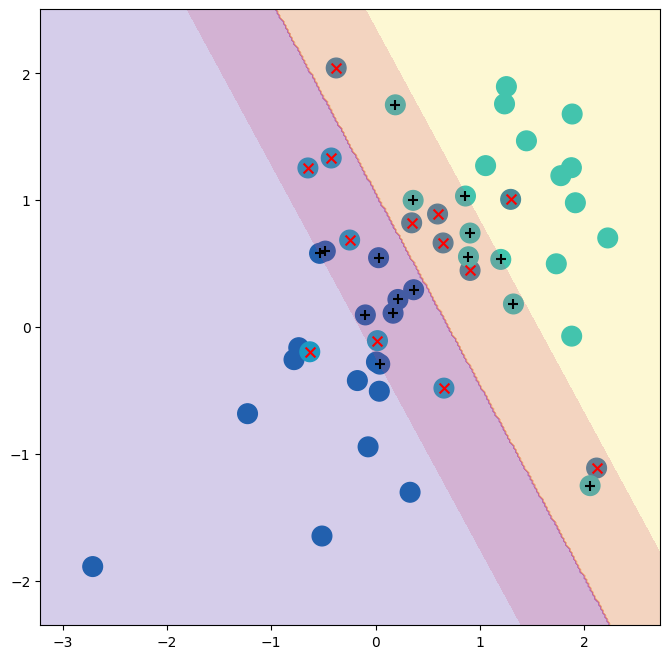

In [24]:
fig, ax = plt.subplots(figsize=(8,8))
plot_svm(X,
         y,
         svm_linear,
         ax=ax)

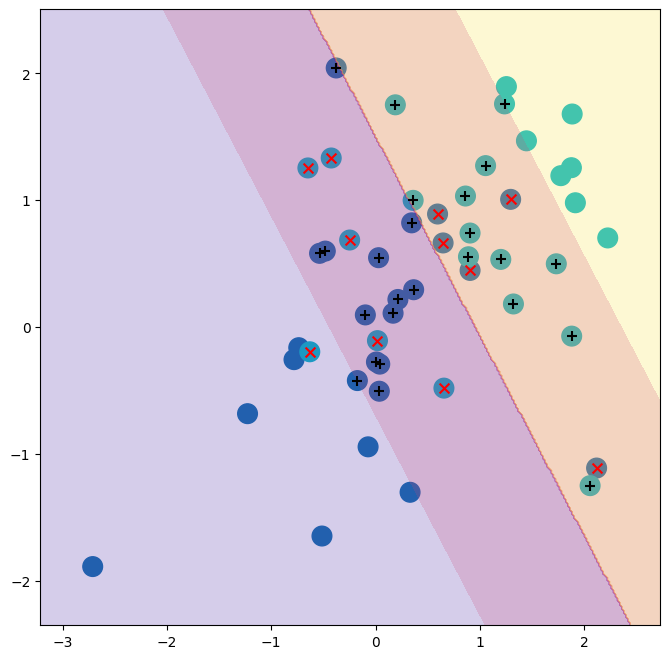

In [16]:
svm_linear_small = SVC(C=0.1, kernel='linear')
svm_linear_small.fit(X, y)
fig, ax = plt.subplots(figsize=(8,8))
plot_svm(X,
         y,
         svm_linear_small,
         ax=ax)

In [18]:
svm_linear.coef_

array([[1.17303943, 0.77348227]])

Hagamos una busqueda de hiperparametros

In [25]:
params = {"C": [0.001, 0.01, 0.1, 1, 5, 10, 100, 1000]}
kfold = skm.KFold(5,
                  random_state=0,
                  shuffle=True)
grid = skm.GridSearchCV(SVC(kernel="linear"),
                        params,
                        refit=True,
                        cv=kfold,
                        scoring="accuracy")
grid.fit(X, y)
grid.best_params_

{'C': 1}

In [27]:
grid.cv_results_[("mean_test_score")]

array([0.46, 0.46, 0.72, 0.74, 0.74, 0.74, 0.74, 0.74])

probamos con algunos datos de prueba

In [32]:
X_test = rng.standard_normal((20, 2))
y_test = np.array([-1]*10 + [1]*10)
X_test[y_test==1] += 1

In [33]:
best = grid.best_estimator_
y_test_hat = best.predict(X_test)
confusion_table(y_test, y_test_hat)

Truth,-1,1
Predicted,,
-1,9,1
1,3,7


Ahora veamos que tal se comporta el modelo con un C = 0.0001

In [34]:
svm_ = SVC(C=0.001,
           kernel="linear").fit(X, y)
y_hat_test = svm_.predict(X_test)
confusion_table(y_test, y_hat_test)

Truth,-1,1
Predicted,,
-1,2,8
1,0,10


In [ ]:
X[y==1] += 1.9

Ahora hagamos un modificacion para que las clases sean perfectamente separables

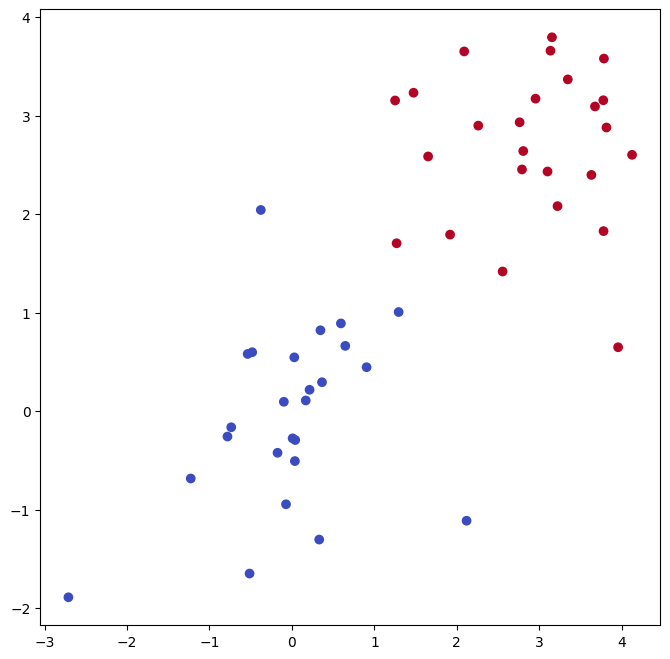

In [41]:
fig, ax = plt.subplots(figsize=(8,8))
ax.scatter(X[:, 0], X[:, 1],
           c=y, cmap=plt.cm.coolwarm)

In [42]:
svm_linear = SVC(C=1e5, kernel='linear')
svm_linear.fit(X, y)

SVC(C=100000.0, kernel='linear')

In [45]:
y_hat_test = svm_linear.predict(X)
confusion_table(y, y_hat_test)

Truth,-1,1
Predicted,,
-1,25,0
1,0,25


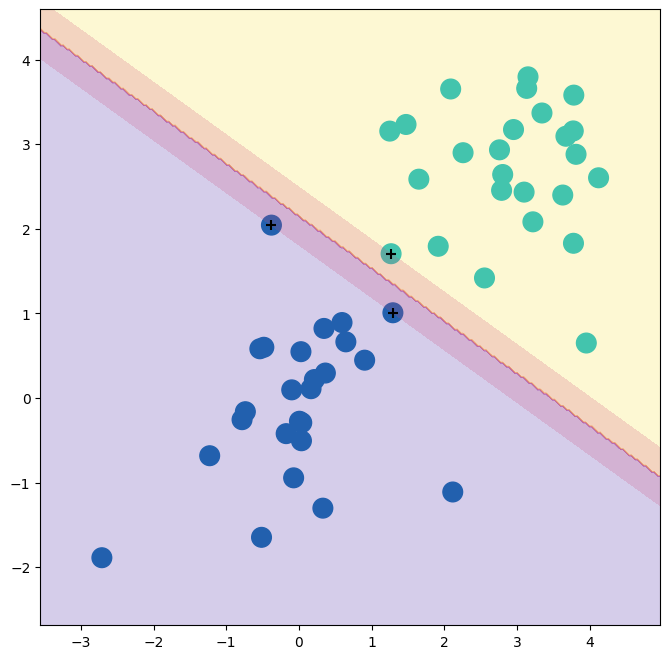

In [46]:
fig, ax = plt.subplots(figsize=(8,8))
plot_svm(X,
         y,
         svm_linear,
         ax=ax)

In [51]:
svm_wider = SVC(C=0.1, kernel='linear')
svm_wider.fit(X, y)
y_hat_test = svm_wider.predict(X)
confusion_table(y, y_hat_test)

Truth,-1,1
Predicted,,
-1,25,0
1,0,25


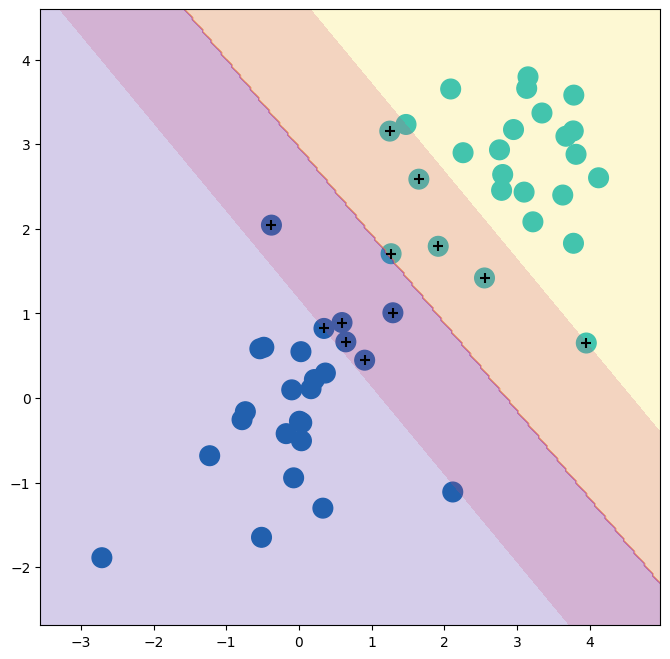

In [52]:
fig, ax = plt.subplots(figsize=(8,8))
plot_svm(X,
         y,
         svm_wider,
         ax=ax)

# Support Vector Machines